# Netflix Show Clustering using Machine Learning
This project groups Netflix shows and movies into clusters based on their characteristics such as type, release year, rating, and duration.The goal is to apply **unsupervised machine learning (K-Means clustering)** to discover patterns within Netflix content.

## Importing the  Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset
The dataset contains information about Netflix movies and TV shows including title, type, release year, rating, duration, and other attributes.

In [5]:
df = pd.read_csv("../data/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


## Handling missing value

In [7]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

## Data cleaning
Removing the rows with missing values.

In [8]:
df = df.dropna(subset=['country','rating','duration'])

## Feature Selection
selecting the relevant features for  cluster formation

In [9]:
data = df[['type','release_year','rating','duration']]
data.head()

,type,release_year,rating,duration
0,Movie,2020,PG-13,90 min
1,TV Show,2021,TV-MA,2 Seasons
4,TV Show,2021,TV-MA,2 Seasons
7,Movie,1993,TV-MA,125 min
8,TV Show,2021,TV-14,9 Seasons


In [10]:
data = df[['type','release_year','rating','duration']]
data.head()

,type,release_year,rating,duration
0,Movie,2020,PG-13,90 min
1,TV Show,2021,TV-MA,2 Seasons
4,TV Show,2021,TV-MA,2 Seasons
7,Movie,1993,TV-MA,125 min
8,TV Show,2021,TV-14,9 Seasons


## Encoding Categorical Features
Machine learning algorithms require numeric data.  
We convert categorical columns like `type` and `rating` into numeric form using encoding.

In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

data['type'] = le.fit_transform(data['type'])
data['rating'] = le.fit_transform(data['rating'])

data.head()

C:\Users\Urvashi Pandey\AppData\Local\Temp\ipykernel_19924\2463245896.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['type'] = le.fit_transform(data['type'])
C:\Users\Urvashi Pandey\AppData\Local\Temp\ipykernel_19924\2463245896.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['rating'] = le.fit_transform(data['rating'])


,type,release_year,rating,duration
0,0,2020,4,90 min
1,1,2021,8,2 Seasons
4,1,2021,8,2 Seasons
7,0,1993,8,125 min
8,1,2021,6,9 Seasons


## Feature Scaling
Features must be scaled so that variables with larger values do not dominate the clustering algorithm.

In [13]:
data.dtypes

type             int64
release_year     int64
rating           int64
duration        object
dtype: object

In [14]:
data['duration'] = data['duration'].str.extract('(\d+)')
data['duration'] = pd.to_numeric(data['duration'])

C:\Users\Urvashi Pandey\AppData\Local\Temp\ipykernel_19924\1939593662.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['duration'] = data['duration'].str.extract('(\d+)')
C:\Users\Urvashi Pandey\AppData\Local\Temp\ipykernel_19924\1939593662.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['duration'] = pd.to_numeric(data['duration'])


In [15]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...


In [16]:
data = data.dropna()

In [18]:
data.dtypes

type            int64
release_year    int64
rating          int64
duration        int64
dtype: object

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

## Finding Optimal Clusters using Elbow Method
The Elbow Method helps determine the optimal number of clusters for K-Means clustering.  
It works by calculating the inertia (within-cluster sum of squares) for different values of K and selecting the point where the decrease in inertia slows down significantly.

In [20]:
from sklearn.cluster import KMeans

inertia = []
K = range(1,10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

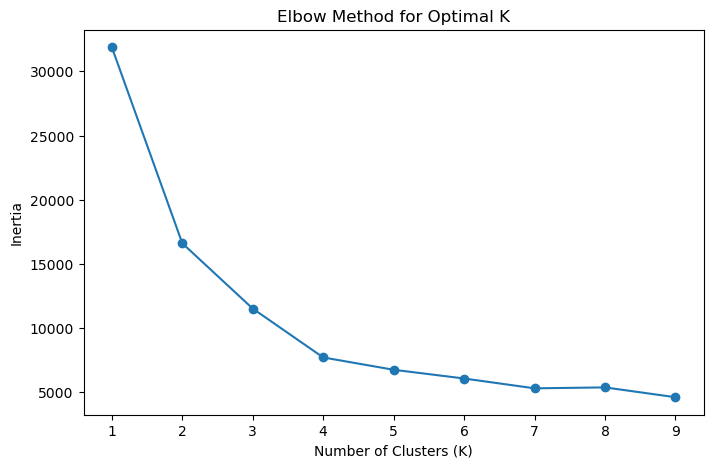

In [21]:
plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.savefig("../images/elbow_method.png")

plt.show()

## Applying K-Means Clustering
Based on the elbow method, we choose the optimal number of clusters and apply the K-Means algorithm to group similar Netflix content.

In [22]:
kmeans = KMeans(n_clusters=4, random_state=42)
data['cluster'] = kmeans.fit_predict(scaled_data)
data.head()

,type,release_year,rating,duration,cluster
0,0,2020,4,90,2
1,1,2021,8,2,0
4,1,2021,8,2,0
7,0,1993,8,125,3
8,1,2021,6,9,0


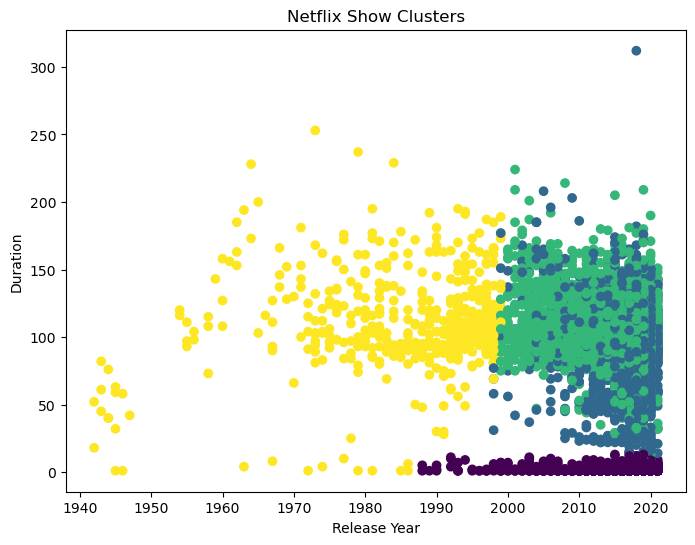

In [23]:
plt.figure(figsize=(8,6))
plt.scatter(data['release_year'], data['duration'], c=data['cluster'], cmap='viridis')
plt.xlabel("Release Year")
plt.ylabel("Duration")
plt.title("Netflix Show Clusters")
plt.savefig("../images/netflix_clusters.png")
plt.show()

In [24]:
#cluster interpretation
data.groupby('cluster').mean()

,type,release_year,rating,duration
cluster,,,,
0,1.000000,2016.699692,7.852048,1.848965
1,0.000000,2016.412571,8.302857,92.509714
2,0.000000,2013.872527,4.975647,106.166286
3,0.026906,1984.755605,5.495516,111.753363


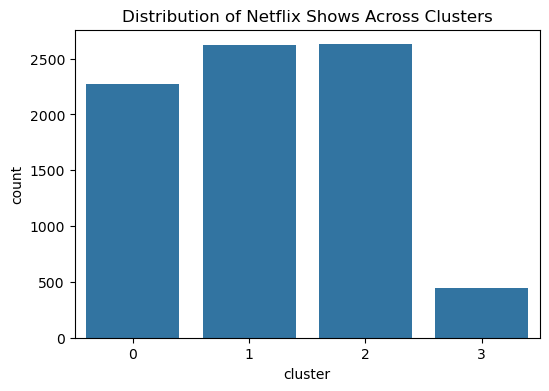

In [25]:
#cluster distribution visualization
plt.figure(figsize=(6,4))
sns.countplot(x='cluster', data=data)
plt.title("Distribution of Netflix Shows Across Clusters")
plt.savefig("../images/cluster_distribution.png")
plt.show()

## Feature Correlation
A correlation heatmap helps us understand relationships between different features used in clustering.

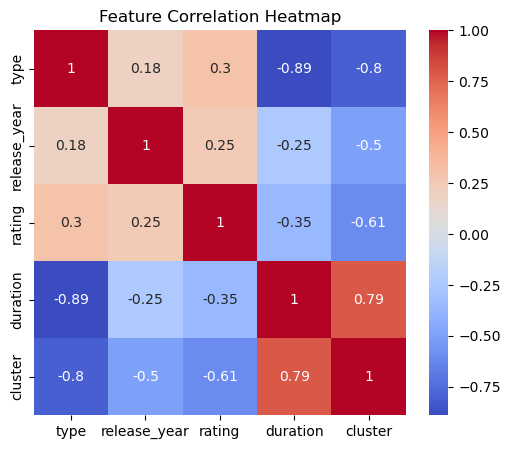

In [26]:
plt.figure(figsize=(6,5))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.savefig("../images/correlation_heatmap.png")
plt.show()